# 视觉对比学习 (Contrastive Learning) 核心笔记：SimCLR 与 MoCo

**核心目标：** 在无标签的情况下，通过最大化同一图像的不同增强视图之间的一致性，让神经网络学会提取具有强大泛化能力的表征（Representation）。这种无监督预训练的底座，能为后续的检测、分割（如复杂背景下的目标识别）以及模型量化部署提供极其鲁棒的特征空间。

---
## 1. 核心直觉：物理学的“弹簧模型”与对比损失

对比学习的本质可以具象化为一个质点弹簧系统：
* **拉力弹簧 (Attract)：** 互为正样本（同一实例的不同增强视图）的特征向量之间存在拉力，促使它们在特征空间中靠近，距离趋于 0。
* **推力弹簧 (Repel)：** 互为负样本（不同实例）的特征向量之间存在推力，迫使它们相互远离，直到超过安全边际（Margin）。

**基础对比损失公式 (Contrastive Loss)：**
$$L(W, Y, \vec{X_1}, \vec{X_2}) = (1 - Y)D_W^2 + Y \cdot \frac{1}{2}(\max\{0, m - D_W\})^2$$
其中，$Y=0$ 表示正样本对（仅保留拉力项），$Y=1$ 表示负样本对（仅保留推力项），$m$ 为推力失效的边界距离。

---

## 2. SimCLR 框架的四大核心组件

SimCLR 证明了无需特殊的网络架构或内存库，只需极简的端到端框架即可实现 SOTA 的自监督效果。

1.  **随机数据增强 (Stochastic Data Augmentation)：**
    * 对输入图像 $x$ 进行两次不同的随机增强，生成正样本对 $\tilde{x}_i$ 和 $\tilde{x}_j$。
    * **关键结论：** **随机裁剪（Crop）+ 随机颜色失真（Color Distortion）** 是最强组合。颜色失真能防止模型利用局部颜色直方图“走捷径”，迫使其学习形状和纹理特征。
2.  **基础编码器 (Base Encoder, $f(\cdot)$)：**
    * 通常使用 ResNet（如 ResNet-50）提取特征表示 $h_i = f(\tilde{x}_i)$。
3.  **非线性投影头 (Non-linear Projection Head, $g(\cdot)$)：**
    * 一个包含隐藏层和 ReLU 激活函数的两层 MLP：$z_i = g(h_i) = W^{(2)}\sigma(W^{(1)}h_i)$。
    * **关键作用：** 保护 $h_i$ 层的特征不被对比损失破坏。对比任务要求特征对颜色、方向等变换保持“不变性”，而在投影头空间 $z_i$ 中计算损失，可以作为“缓冲”，使得 $h_i$ 依然能保留用于下游任务的丰富语义。
4.  **NT-Xent 损失函数 (Normalized Temperature-scaled Cross Entropy)：**
    * 在投影空间 $z$ 中计算，利用余弦相似度和温度参数 $\tau$ 对样本难度进行加权。

---

## 3. NT-Xent 损失函数深度解析

对于大小为 $N$ 的 Batch，经过增强后得到 $2N$ 个样本。对于任意样本 $i$，在剩下的 $2N-1$ 个样本中找寻其唯一的正样本 $j$。

$$l_{i,j} = -\log \frac{\exp(\text{sim}(z_i, z_j)/\tau)}{\sum_{k=1}^{2N} \mathbb{1}_{[k \neq i]} \exp(\text{sim}(z_i, z_k)/\tau)}$$

* $\text{sim}(z_i, z_j)$：$l_2$ 归一化后的点积（即余弦相似度）。
* $\tau$ **(Temperature)：** 温度参数。较小的 $\tau$ 会放大“困难负样本”（Hard Negatives，即长得像但实际是异类的样本）产生的梯度，强迫模型更精细地划分特征空间。

---


```python
import torch
import torch.nn as nn
import torch.nn.functional as F

class NTXentLoss(nn.Module):
    def __init__(self, temperature=0.5):
        super(NTXentLoss, self).__init__()
        self.temperature = temperature

    def forward(self, z_i, z_j):
        """
        z_i: 视图1的特征向量 [batch_size, feature_dim]
        z_j: 视图2的特征向量 [batch_size, feature_dim]
        """
        batch_size = z_i.shape[0]
        
        # 1. 拼接所有特征 [2*batch_size, feature_dim] 并进行 L2 归一化
        z = torch.cat([z_i, z_j], dim=0)
        z = F.normalize(z, p=2, dim=1)
        
        # 2. 计算相似度矩阵 [2*batch_size, 2*batch_size]
        sim_matrix = torch.matmul(z, z.T) / self.temperature
        
        # 3. 构建标签 (正样本的索引)
        # 对于 z_i 的正样本是 z_j (索引偏移 batch_size)
        # 对于 z_j 的正样本是 z_i (索引偏移 -batch_size)
        labels = torch.cat([torch.arange(batch_size) + batch_size, 
                            torch.arange(batch_size)], dim=0).to(z.device)
        
        # 4. 掩码操作：把对角线元素（自己与自己的相似度）设为极小值，排除在外
        mask = torch.eye(2 * batch_size, dtype=torch.bool).to(z.device)
        sim_matrix.masked_fill_(mask, -1e9)
        
        # 5. 计算交叉熵损失
        loss = F.cross_entropy(sim_matrix, labels)
        
        return loss

# 实例化测试 (模拟 Batch Size = 32, 特征维度 128)
criterion = NTXentLoss(temperature=0.1)
dummy_z_i = torch.randn(32, 128)
dummy_z_j = torch.randn(32, 128)
loss_value = criterion(dummy_z_i, dummy_z_j)
print(f"NT-Xent Loss computed: {loss_value.item():.4f}")

# MoCo对比学习：

* 1.目标函数

* 2.代理任务：
    用途：生成一个自监督的信号，去充当**ground turth**这个标签信息。

* 3.损失函数：
    
    这是对比学习中非常经典的 **InfoNCE 损失函数**（noise constrative estimiation）公式

$$
\mathcal{L}_q = -\log \frac{\exp(q \cdot k_+ / \tau)}{\sum_{i=0}^K \exp(q \cdot k_i / \tau)}
$$

---

**公式里各个符号代表的含义：**

* **$q$ (Query)**：你的“原图”提取出的特征向量（Anchor）。
* **$k_+$ (Positive Key)**：同源的“正样本”提取出的特征向量。
* **$q \cdot k_+$**：表示原图和正样本在特征空间中的**相似度**（点积运算）。分子部分想让这个相似度越大越好。
* **$k_i$ (Keys)**：字典里所有的样本特征，包含了 $1$ 个正样本和 $K$ 个负样本。
* **分母部分 $\sum$**：表示计算原图 $q$ 与所有样本（正+负）的相似度总和。损失函数希望正样本的相似度在总和中占据绝对主导地位，从而隐式地“推开”那些负样本。
* **$\tau$ (Temperature)**：温度超参数，用来控制模型对困难负样本（Hard Negatives）的惩罚力度。温度系数越大，曲线越平缓，对所有的负样本一视同仁，不会去对困难负样本做优化；温度系数过小，曲线越尖锐，导致模型特别关注困难负样本，简单负样本的概率几乎为零，困难负样本在分母中所占的比例会增大，使得模型能更好的区分锚点与困难负样本，但同时会忽略简单负样本。

---
### 1. 对比学习的新视角：构建动态字典
作者提出，对比学习本质上是在高维连续数据（比如图像）上构建一个**离散的字典**。
这个字典是**动态的 (dynamic)**，原因有两点：
* 字典里的“键”（Keys，即样本特征）是不断随机采样的。
* 负责提取这些特征的“键编码器”（Key Encoder）在整个训练过程中也在不断地演进和更新。

### 2. 核心假设：如何学到好特征？
作者提出了一个极其重要的假设，认为想要学到优秀的特征表示，必须同时满足两个条件：
* **大容量 (Large)：** 字典必须足够大，这样才能包含极其丰富的负样本（Negative Samples），迫使模型学到更有区分度的特征。
* **一致性 (Consistent)：** 尽管生成字典键的编码器在不断进化，但它的变化过程必须尽可能保持平滑和一致。如果编码器更新过于剧烈，字典里新旧特征的标准就不统一了，这会严重破坏对比学习的效果。

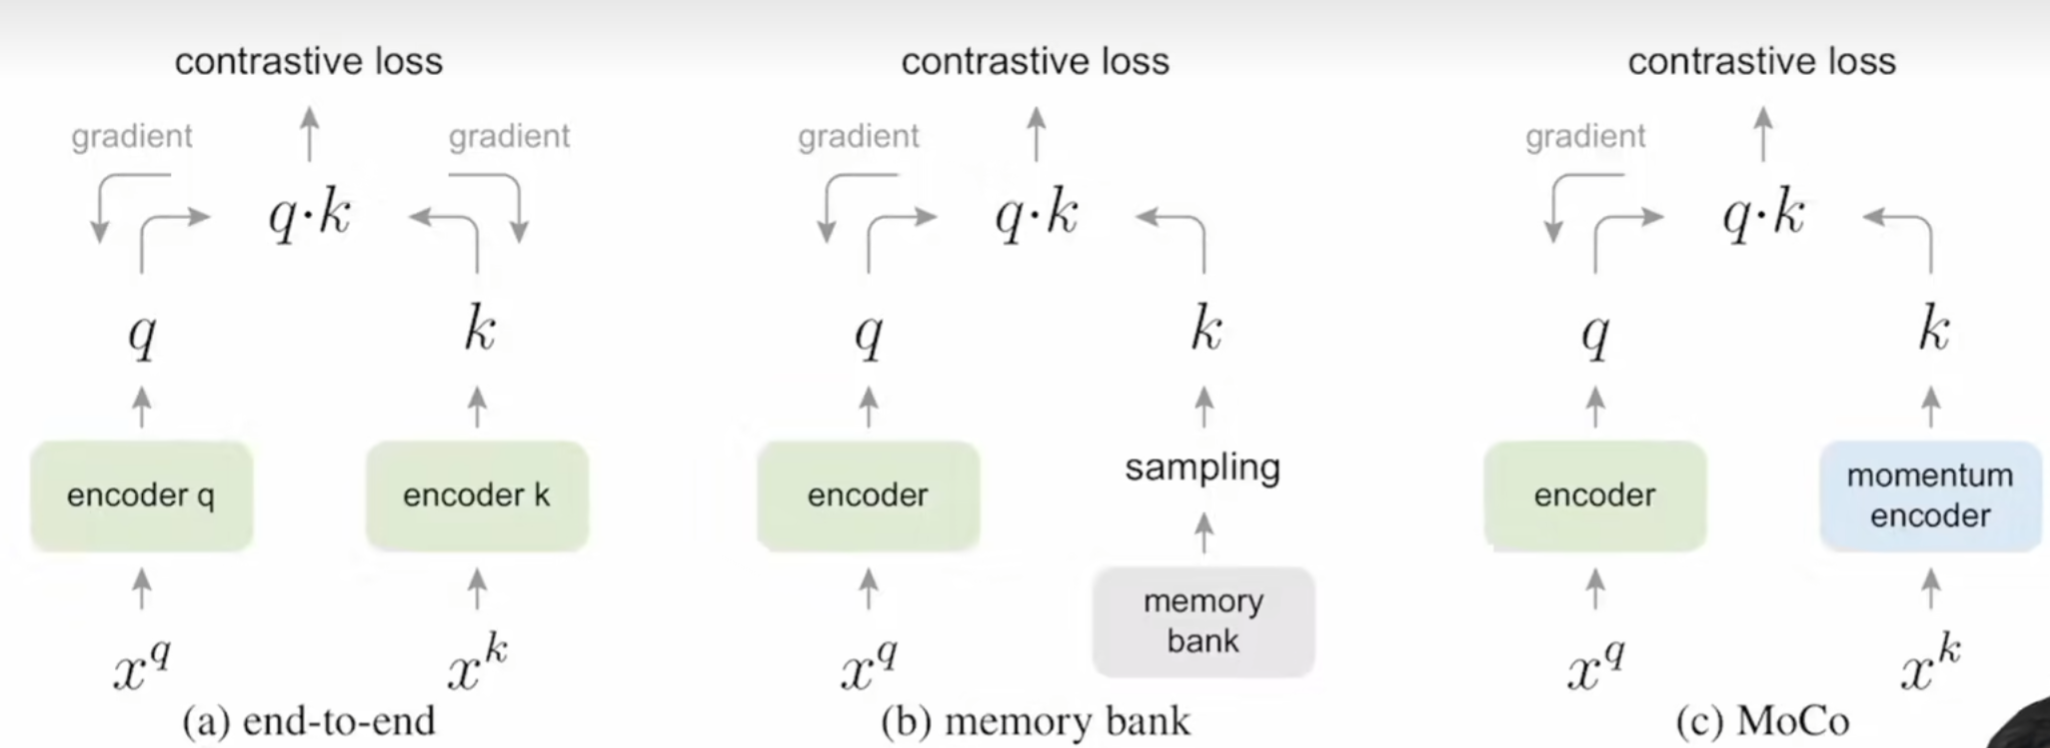



   


---

### 1. 之前的痛点：为什么“大容量”与“一致性”难以兼得？

在对比学习中，字典里的负样本越多（大容量），模型面临的挑战就越大，学到的特征就越具有判别力。同时，生成这些样本特征的标准必须统一（一致性），否则模型就会陷入混乱。

#### 痛点一：端到端方法 (End-to-End) —— 受限于“大容量”
这是最直观的训练方式。原图 ($q$) 和正负样本 ($k$) 分别通过两个编码器（通常参数共享），然后**同时进行梯度反向传播**来更新这两个编码器。
* **一致性：完美。** 因为所有的 $q$ 和 $k$ 都是在当前这**同一次**迭代中，由最新状态的编码器计算出来的，特征标准绝对统一。
* **大容量：严重受限。** 字典的大小 $K$ 强行绑定了当前训练的批次大小 (Batch Size)。要想字典大，Batch Size 就得大。但在高分辨率图像（比如目标检测场景）和深层网络下，GPU 显存会瞬间爆炸。因此，端到端方法的字典容量注定很小，模型见不到足够的负样本，特征学得不够深。

#### 痛点二：记忆库方法 (Memory Bank) —— 受限于“一致性”
为了打破显存的限制，研究者想出了一招：建立一个“离线”的巨大特征库，把整个数据集里所有图片的特征都存进去。每次训练时，把当前批次计算出的 $q$ 和记忆库里抽样的 $k$ 拿来算损失。同时使用更新后的编码器计算抽样的 $k$ 的最新的向量表示。直接将原先的表示覆盖掉。
* **大容量：完美。** 字典的大小可以等同于整个数据集的大小，负样本极其丰富。
* **一致性：严重受限。** 致命缺陷在于，记忆库里的那些 $k$ 是在过去的**不同 epoch、不同迭代时刻**被提取并存进去的。这意味着，当你用当前最新进化的编码器提取出 $q$ 时，你去和记忆库里那些“老旧（Stale）”的 $k$ 做对比。这就像拿明朝的剑斩清朝的官，特征编码的尺度和语义空间可能已经发生了漂移，导致对比损失计算极其不准确。自己的理解，在一个epoch中，每个k的向量表征只更新一次，但是编码器会更新很多次，这就导致当我启动下一个epoch训练的时候，得到的q要比当前存储在记忆库里面的k新的多，从而导致特征的不一致性。

---

### 2. MoCo 的核心贡献：破局之法

MoCo 巧妙地引入了两个机制，分别斩断了上述两个限制。

#### 贡献一：用“队列 (Queue)”机制实现大容量
MoCo 放弃了把字典和 Batch Size 绑定的做法，而是把字典维护成一个**滑动队列**。
* 每次有新的一个 Batch 的样本经过 Key 编码器算完特征后，就直接**入队**。
* 队列满了之后，最老的那批特征就**出队**抛弃。
* **突破点：** 因为不需要对 Key 编码器进行全量反向传播计算梯度（省去了极大的显存开销），这个队列可以开得非常巨大（例如 MoCo 默认的 $K = 65536$），轻而易举地实现了“大容量”。

在 MoCo（Momentum Contrast）中：
- **队列（queue）** 存储的是**历史 batch 中由 momentum encoder 产生的 key 特征**，对于当前 batch 中的每一个 query `q` 而言，队列里的所有样本都是**负样本**。
- **正样本** 则是当前 batch 中与 `q` 配对的 `k`（由 momentum encoder 对同一 batch 的另一个增强视图编码得到），它**不在队列中**，而是通过当前前向传播实时计算得到。

所以可以简洁地总结为：
> **队列存负样本，当前批次提供正样本。**

#### 贡献二：用“动量编码器 (Momentum Encoder)”保证一致性
既然 Key 编码器不通过反向传播更新，那它怎么进化呢？如果它不更新，新入队的特征和老特征同样会存在一致性问题。
MoCo 的神仙操作是：**让 Key 编码器的参数变成 Query 编码器参数的“指数移动平均 (EMA)”。**

其更新公式为：
$$
\theta_k \leftarrow m \theta_k + (1 - m) \theta_q
$$
* $\theta_k$ 是 Key 编码器的参数，$\theta_q$ 是 Query 编码器（通过梯度正常更新）的参数。
* $m$ 是动量系数，MoCo 极其激进地将其设置得非常大，比如 **$m = 0.999$**。

**突破点：** 因为 $m$ 极大，Key 编码器 $\theta_k$ 每次只会吸收极小一部分 $\theta_q$ 的新变化。它的演进变得**极其缓慢和丝滑**。这样一来，虽然队列里那 65536 个负样本是在过去不同的迭代步中生成的，但由于 Key 编码器在这些步骤里的变化微乎其微，这些样本的特征分布保持了极高的**一致性**。

---

```python
# 模拟 MoCo 的数据增强策略与动量更新逻辑 (伪代码核心结构)
import torchvision.transforms as transforms

# 论文建议的最强数据增强组合：Crop + Color Distortion + Gaussian Blur
moco_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.2, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomApply([
        transforms.ColorJitter(0.4, 0.4, 0.4, 0.1)  # 强烈的颜色扰动
    ], p=0.8),
    transforms.RandomGrayscale(p=0.2),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=23)], p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def momentum_update(model_q, model_k, m=0.999):
    """
    执行动量更新：将 Query 网络的参数缓慢转移到 Key 网络
    这在解决 QAT（量化感知训练）中教师/学生网络特征对齐时也非常有启发。
    """
    for param_q, param_k in zip(model_q.parameters(), model_k.parameters()):
        param_k.data = param_k.data * m + param_q.data * (1. - m)
```